# Interacting with prop datasets

To know
- Distribution of lengths -> compute cut-offs
- Distribution of splits -> compute splits

In [1]:
from multiprocessing import Pool

import datasets
import matplotlib.pyplot as plt
import numpy as np
from transformers import AutoTokenizer
from tqdm import tqdm

from prop import *

datasets.disable_caching()

In [64]:
# ds_path = full_text_ds_path
ds_path = '/n/home09/wlt/scratch/data/prop_gen/data/hf_full_text'
ds = datasets.load_from_disk(ds_path)
ds

DatasetDict({
    True_2: Dataset({
        features: ['is_true', 'length', 'ops', 'prompt', 'completion'],
        num_rows: 202317
    })
    False_2: Dataset({
        features: ['is_true', 'length', 'ops', 'prompt', 'completion'],
        num_rows: 176243
    })
    True_3: Dataset({
        features: ['is_true', 'length', 'ops', 'prompt', 'completion'],
        num_rows: 157035
    })
    False_3: Dataset({
        features: ['is_true', 'length', 'ops', 'prompt', 'completion'],
        num_rows: 216163
    })
    True_4: Dataset({
        features: ['is_true', 'length', 'ops', 'prompt', 'completion'],
        num_rows: 165150
    })
    False_4: Dataset({
        features: ['is_true', 'length', 'ops', 'prompt', 'completion'],
        num_rows: 208434
    })
    True_5: Dataset({
        features: ['is_true', 'length', 'ops', 'prompt', 'completion'],
        num_rows: 154870
    })
    False_5: Dataset({
        features: ['is_true', 'length', 'ops', 'prompt', 'completion'],
      

In [52]:
np.sum([len(d) for d in ds.values()])

np.int64(8657010)

In [53]:
ds.cleanup_cache_files()

{'True_3': 0,
 'False_3': 0,
 'True_4': 0,
 'True_5': 0,
 'False_5': 0,
 'True_6': 0,
 'True_7': 0,
 'False_7': 0,
 'True_8': 0,
 'True_9': 0,
 'False_9': 0,
 'True_10': 0,
 'True_11': 0,
 'False_11': 0,
 'True_12': 0,
 'True_13': 0,
 'False_13': 0,
 'True_14': 0,
 'True_15': 0,
 'False_15': 0,
 'True_16': 0,
 'True_17': 0,
 'False_17': 0,
 'True_18': 0,
 'True_19': 0,
 'False_19': 0,
 'True_20': 0,
 'True_21': 0,
 'False_21': 0,
 'True_22': 0,
 'True_23': 0,
 'False_23': 0,
 'True_24': 0,
 'True_25': 0,
 'False_25': 0,
 'True_26': 0,
 'True_27': 0,
 'False_27': 0,
 'True_28': 0,
 'True_29': 0,
 'False_29': 0,
 'True_30': 0,
 'True_31': 0,
 'False_31': 0,
 'True_32': 0,
 'True_33': 0,
 'False_33': 0,
 'True_34': 0,
 'True_35': 0,
 'False_35': 0,
 'True_36': 0,
 'True_37': 0,
 'False_37': 0,
 'True_38': 0,
 'True_39': 0,
 'False_39': 0,
 'True_40': 0,
 'True_41': 0,
 'False_41': 0,
 'True_42': 0,
 'True_43': 0,
 'False_43': 0,
 'True_44': 0,
 'True_45': 0,
 'False_45': 0,
 'True_46': 0,

Text(0, 0.5, 'number of examples')

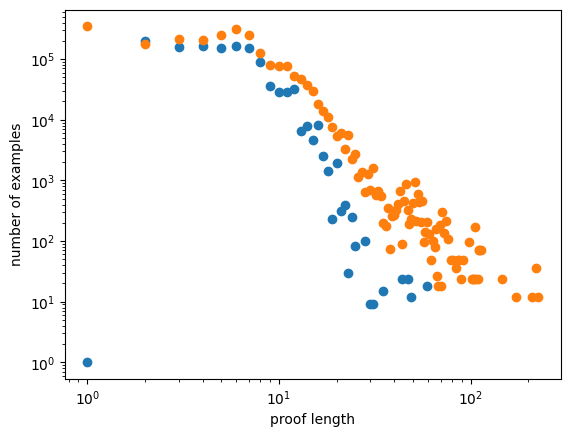

In [65]:
t_vals = []
f_vals = []
a_vals = {}

for k, v in ds.items():
    name, num = k.split('_')

    if name == 'True':
        t_vals.append((int(num), len(v)))
    else:
        f_vals.append((int(num), len(v)))
    
    if int(num) not in a_vals:
        a_vals[int(num)] = len(v)
    else:
        a_vals[int(num)] += len(v)
        

a_vals = list(a_vals.items())

# <codecell>
import matplotlib.pyplot as plt

t_idx, t_lens = np.array(t_vals).T
f_idx, f_lens = np.array(f_vals).T
a_idx, a_lens = np.array(a_vals).T

plt.scatter(t_idx, t_lens)
plt.scatter(f_idx, f_lens)

plt.xscale('log')
plt.yscale('log')
plt.xlabel('proof length')
plt.ylabel('number of examples')

In [61]:
print(f_idx)
print(f_lens)

[  2   3   4   5   6   7   8   9  11  10  12  13  15  14  17  18  16  20
  21  22  23  25  24  27  19  32  29  40  39  26  34  37  36  35  33  54
  59  31  44  41  86  28  45  30  57  46  49  43  67  48  52  89  87 121
  47  61  66  82  42  53  51  55  60  64  56  58  38  68  65 130  63  69
 138  73  79  75  62  74  76  97 157  71  90  88  50  98 122  70 123 144
  83 114  94  84  77  95 120 111 119 140 134 155 131 129 141  91 116 200
 212 132 167 118  92 117 142  81 151  85  93 133 178 137  99 115 109  96
  72 271 145 101  78 104  80 105 113 128 166 102 179 110 230 103 106 108
 262 181 185 124 100 209 242 127 164 177 169 153 160 161 260 182 168 107
 112 148 250 188 196 331 176 184 222 241 248 249 256 125 175 229 355 192
 344 172 341 352 365 255 147 203 367 375 425 162 813 186 163 261 240 401
 281 294 170 173 183 156 159 154 217 152 165 246 210 336 265 324 189 126
 237 180 346 518 529 193 198 438 322 305 135 187 201 440 139 277 243 221
 219 419 284 351 286 686 218 345 149 353 519 213   

prop | t_idx | f_idx | a_idx
------------------------------
 0.2:     2      1      2
 0.4:     3      4      3
 0.5:     4      4      4
 0.6:     5      5      5
 0.8:     7      8      7
 0.9:     8     11     10
0.95:    11     14     13


Text(0, 0.5, 'cumulative proportion of examples')

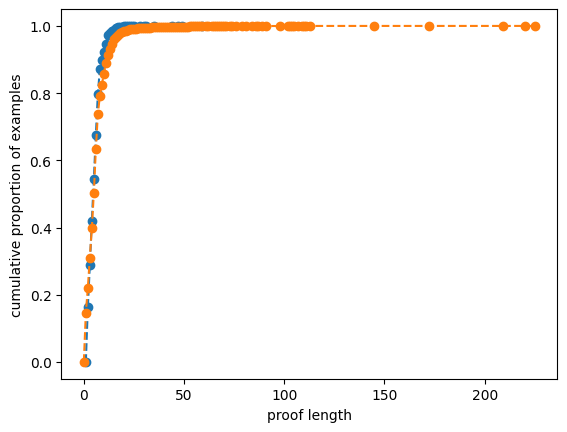

In [66]:
t_sort_idx = np.argsort(t_idx)
t_cum = np.cumsum(t_lens[t_sort_idx]) / np.sum(t_lens)

f_sort_idx = np.argsort(f_idx)
f_cum = np.cumsum(f_lens[f_sort_idx]) / np.sum(f_lens)

a_sort_idx = np.argsort(a_idx)
a_cum = np.cumsum(a_lens[a_sort_idx]) / np.sum(a_lens)

plt.plot(np.sort(t_idx), t_cum, 'o--')
plt.plot(np.sort(f_idx), f_cum, 'o--')

props = [0.2, 0.4, 0.5, 0.6, 0.8, 0.9, 0.95]

t_idxs = []
f_idxs = []
a_idxs = []

for p in props:
    idx = np.sum(t_cum < p) - 1
    t_idxs.append(t_idx[t_sort_idx][idx].item())
    
    idx = np.sum(f_cum < p) - 1
    f_idxs.append(f_idx[f_sort_idx][idx].item())
    
    idx = np.sum(a_cum < p) - 1
    a_idxs.append(a_idx[a_sort_idx][idx].item())

print(f'prop | t_idx | f_idx | a_idx')
print('------------------------------')
for prop, t, f, a in zip(props, t_idxs, f_idxs, a_idxs):
    print(f'{prop:4}: {t:5} {f:6} {a:6}')

plt.xlabel('proof length')
plt.ylabel('cumulative proportion of examples')

In [68]:
split_len = 4

t_idx_sort = t_idx[t_sort_idx]
f_idx_sort = f_idx[f_sort_idx]

tot_t = np.sum(t_lens)
tot_f = np.sum(f_lens)

t_boundary = np.sum(t_idx_sort <= split_len) - 1
n_t_train = t_cum[t_boundary] * tot_t
n_t_test = tot_t - n_t_train

f_boundary = np.sum(f_idx_sort <= split_len) - 1
n_f_train = f_cum[f_boundary] * tot_f
n_f_test = tot_f - n_f_train

assert n_t_train + n_t_test + n_f_train + n_f_test == tot_t + tot_f

prob_guess_t = n_t_train / (n_t_train + n_f_train)
prob_guess_f = 1 - prob_guess_t

prob_chance = (prob_guess_t * n_t_test + prob_guess_f * n_f_test) / (n_t_test + n_f_test)
prob_chance = prob_chance.round(2).item()

print(f'{prob_chance = }')

prob_chance = 0.55


In [9]:
tokenizer = AutoTokenizer.from_pretrained('Qwen/Qwen2.5-Coder-7B')

def to_toks(ex):
    inp_and_proof_toks = tokenizer(ex['prompt'] + ex['completion'], return_attention_mask=False)

    return {
        'tok_len': len(inp_and_proof_toks['input_ids']),
    }

ds = ds.map(to_toks, batched=False, num_proc=24)

num_proc must be <= 8. Reducing num_proc to 8 for dataset of size 8.


Map (num_proc=8):   0%|          | 0/8 [00:00<?, ? examples/s]

Map (num_proc=24):   0%|          | 0/64 [00:00<?, ? examples/s]

Map (num_proc=24):   0%|          | 0/256 [00:00<?, ? examples/s]

num_proc must be <= 16. Reducing num_proc to 16 for dataset of size 16.


...

Map (num_proc=2):   0%|          | 0/2 [00:00<?, ? examples/s]

num_proc must be <= 3. Reducing num_proc to 3 for dataset of size 3.


Map (num_proc=3):   0%|          | 0/3 [00:00<?, ? examples/s]

num_proc must be <= 1. Reducing num_proc to 1 for dataset of size 1.


Map:   0%|          | 0/1 [00:00<?, ? examples/s]

In [10]:
def slice_dataset(ds, start, stop):
    all_ds = []

    for key in ds.keys():
        name, i = key.split('_')
        i = int(i)

        if start <= i < stop:
            all_ds.append(ds[key].remove_columns('ops'))

    if len(all_ds) == 0:
        return ds[key].select(range(0))  # empty dataset

    return datasets.concatenate_datasets(all_ds)

train_ds = slice_dataset(ds, 0, 18)
test_ds = slice_dataset(ds, 19, np.inf)

In [11]:
def get_len(ex):
    return ex['tok_len']

with Pool(24) as pool:
    train_lens = pool.map(get_len, train_ds)
    test_lens = pool.map(get_len, test_ds)

array([2246.  , 2442.  , 3261.  , 3422.  , 3442.  , 3456.72, 3473.  ])

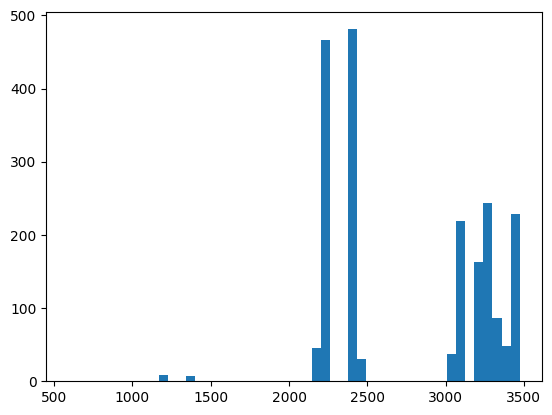

In [12]:
plt.hist(train_lens, bins=50)
np.quantile(train_lens, [0.25, 0.5, 0.75, 0.9, 0.95, 0.99, 1])

array([20390. , 21186. , 22928. , 23678. , 28234. , 32299.6, 32768. ])

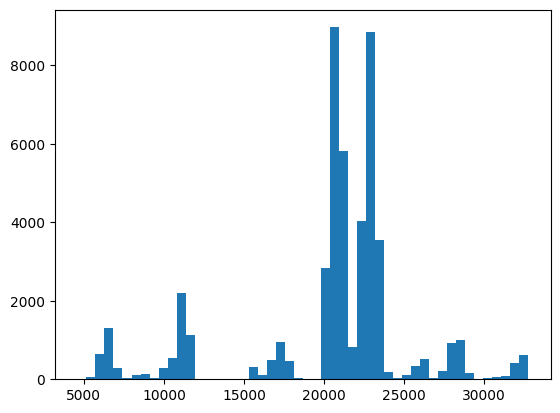

In [13]:
plt.hist(test_lens, bins=50)
np.quantile(test_lens, [0.25, 0.5, 0.75, 0.9, 0.95, 0.99, 1])

In [ ]:
test_lens = np.array(test_lens)
np.mean(test_lens < 32_768)

In [ ]:
train_lens = np.array(train_lens)
np.mean(train_lens < 8192)

In [14]:
(np.sum(train_lens) + np.sum(test_lens)) / 1e9

np.float64(1.004140211)

## Length distributions for different datasets

Full
```
prop | t_idx | f_idx | a_idx
------------------------------
 0.2:     2      1      2
 0.4:     3      4      3
 0.5:     4      4      4
 0.6:     5      5      5
 0.8:     7      8      7
 0.9:     8     11     10
0.95:    11     14     13
```


Imply
```
prop | t_idx | f_idx | a_idx
------------------------------
 0.2:     2     11      3
 0.4:     3     14      5
 0.5:     3     17      9
 0.6:     3     20     12
 0.8:     5     28     21
 0.9:     8     41     29
0.95:    12     56     42
```


Or
```
prop | t_idx | f_idx | a_idx
------------------------------
 0.2:     3     13      3
 0.4:     5     13      5
 0.5:     6     13      6
 0.6:     7     13      7
 0.8:    10     13     10
 0.9:    12     13     13
0.95:    13     13     14
```

Or (par)
```
prop | t_idx | f_idx | a_idx
------------------------------
 0.2:     6      9      7
 0.4:    11     19     14
 0.5:    14     23     18
 0.6:    18     29     24
 0.8:    28     39     36
 0.9:    36     45     44
0.95:    42     49     48
```


PHP
```
prop | t_idx | f_idx | a_idx
------------------------------
 0.2:    15     55     58
 0.4:    36     55     58
 0.5:    42     71     58
 0.6:    42     71     84
 0.8:    80     92     92
 0.9:    82    100     92
0.95:   143    104    110
```

PHP (par)
```
prop | t_idx | f_idx | a_idx
------------------------------
 0.2:    20     66     33
 0.4:    31    104     59
 0.5:    36    122     76
 0.6:    44    147     97
 0.8:    64    208    169
 0.9:    82    268    220
0.95:    91    306    277
```

PHP (enum)

```
prop | t_idx | f_idx | a_idx
------------------------------
 0.2:    21     86     44
 0.4:    49    118     69
 0.5:    57    118     75
 0.6:    67    118     87
 0.8:    80    128    118
 0.9:    88    186    125
0.95:    90    210    167
```

### Length quantiles

TODO: can shorten context length during training for these two

Full:

3630455 points, 1.4 billion tokens
prob_chance = 0.55

max train length < 512
max test length <~ 2048

```
[ 0.25,   0.5,  0.75,   0.9,  0.95,  0.99]
[ 189.,  370.,  537.,  688.,  783., 1144.]
```


Implies:
11015905 points, 11.6 billion tokens
prob_chance = 0.15

max train length < 1024
max test length <~ 16,384

```
[ 0.25,   0.5,  0.75,   0.9,  0.95,  0.99, max]
[ 275.,  634., 1126., 2117., 3125., 7494., 94357]
```

Or (par):
8657010 points, 78.5 billion tokens
prob_chance = 0.47

max train length <~ 8192
max test length <~ 32,768



PHP (enum):
50786 points, 1.0 billion tokens tokens
prob_chance = 0.58


PHP (par)
168702 points, 2.5 billion tokens
max train/test length <~ 32,768

```
[ 0.25,   0.5,  0.75,   0.9,  0.95,  0.99, max]
[12732., 18542., 25357., 29543., 31087., 32366., 32751.]
```
